# Synthetic campaign scenarios for Reference-ID reach calibration

This notebook tests whether Reference-ID calibration improves union reach for plausible campaign types beyond broad awareness/reach. It compares:

1. **Existing VID baseline:** each EDP's VID reach is retained, while cross-EDP overlap is estimated at the population rate.
2. **Pair-aware fixed + log calibration:** Reference-ID intersections are decoded using a frozen model that allows EDP-pair affinity and a bounded campaign-size effect.
3. **Two-group matchability mixture:** Reference-ID intersections are decoded using two latent groups of people with different probabilities of being linkable at each EDP.

The calibration models were fitted once on large, broad-reach synthetic campaigns and then frozen. All scenarios below are out-of-sample campaign simulations. Synthetic truth is visible only to this validation notebook; the reporting method itself never links a VID to a Reference ID.

**Important:** these scenarios are stylized tests inspired by real Meta objectives and audience tools. They are not estimates of Meta production audience distributions or product performance.

**Method update:** the headline comparison now includes two pairwise-inference methods from the separate [calibration method benchmark](calibration_method_benchmark.ipynb). One calibrates pairs with the bounded direct fixed-plus-log model; the other calibrates pairs with the two-group matchability mixture. Both infer higher orders using maximum entropy.

## Why these scenarios are plausible

Meta's current campaign objectives include Awareness, Traffic, Engagement, Leads, App promotion, and Sales. Audience construction can also use customer lists, website or app activity, engagement audiences, lookalikes, detailed targeting, exclusions, and automated audience expansion. Those choices affect who actually receives an ad:

- broad awareness delivery can resemble the population used to train a conventional reach model;
- conversion, lead, or engagement optimization can repeatedly select people with shared intent;
- website, app, or customer-list retargeting can create small and highly overlapping audiences;
- lookalikes and audience expansion can blend seed-audience affinity with broader delivery; and
- first-party customer lists can select people who are unusually easy to match by email, while app or engagement audiences may shift matchability in the other direction.

Sources for product terminology: [Meta Ads Manager objectives](https://en-gb.facebook.com/business/m/small-business/am-advertiser-success-center/ad-creation/objective) and [Meta Website Custom Audiences](https://developers.facebook.com/documentation/ads-commerce/marketing-api/audiences/guides/website-custom-audiences).

In [1]:
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "synthetic_validation"]
    for candidate in candidates:
        if (candidate / "src" / "reference_calibration").exists():
            return candidate.resolve()
    raise RuntimeError("Run this notebook from the repository root or notebooks/.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from reference_calibration.config import SimulationConfig
from reference_calibration.evaluation import calibrate_report, relative_error
from reference_calibration.joint_decoding import calibrate_report_pairwise_maximum_entropy
from reference_calibration.measurement import measure_report
from reference_calibration.models import calibration_model_from_dict
from reference_calibration.population import generate_campaign, make_world
from reference_calibration.research_models import DirectPairLogModel

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "meta_campaign_scenarios"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project: repository root")
print(f"Outputs: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Project: repository root
Outputs: outputs/meta_campaign_scenarios


## Scenario catalog

Each row states the real advertising mechanism that motivates the test and the synthetic behavior used to represent it. “More overlap” means the reached audiences at different EDPs share more of the same people than a population-rate assumption would predict. “Matchability” means the probability that a reached person supplies the common email-derived Reference ID at all required EDPs.

In [2]:
SCENARIO_CATALOG = [
    {
        "scenario": "broad_awareness_control",
        "label": "Broad awareness / reach control",
        "meta_mechanism": "Awareness objective with broad delivery",
        "synthetic_behavior": "Large audiences; weak shared selection; calibration-like population",
        "test_question": "Does calibration avoid damaging the use case where today's VID model should already work?",
    },
    {
        "scenario": "traffic_optimization",
        "label": "Traffic / landing-page views",
        "meta_mechanism": "Traffic objective optimized for clicks or landing-page views",
        "synthetic_behavior": "Medium reach; modest shared consideration signal",
        "test_question": "Can calibration handle a moderately selected mid-funnel audience?",
    },
    {
        "scenario": "video_engagement_retargeting",
        "label": "Video or engagement retargeting",
        "meta_mechanism": "Engagement objective or an audience of prior viewers/engagers",
        "synthetic_behavior": "Warm, correlated audience; no assumed email advantage",
        "test_question": "Does it recover overlap when multiple EDPs repeatedly find the same engagers?",
    },
    {
        "scenario": "lead_generation",
        "label": "Lead generation",
        "meta_mechanism": "Leads objective optimized for forms, calls, messages, or sign-ups",
        "synthetic_behavior": "Narrow high-intent audience; moderately elevated contactability",
        "test_question": "Does it work when delivery selects people more likely to provide contact information?",
    },
    {
        "scenario": "sales_prospecting",
        "label": "Sales / purchase prospecting",
        "meta_mechanism": "Sales objective optimized for purchase or another conversion",
        "synthetic_behavior": "Small-to-medium audiences sharing latent purchase intent",
        "test_question": "Does it correct the extra duplication caused by conversion optimization?",
    },
    {
        "scenario": "website_retargeting",
        "label": "Website retargeting",
        "meta_mechanism": "Website Custom Audience such as visitors or cart viewers",
        "synthetic_behavior": "Small, highly correlated audience",
        "test_question": "Can it correct the severe case where multiple EDPs reach the same warm users?",
    },
    {
        "scenario": "crm_customer_list",
        "label": "Customer-list retargeting",
        "meta_mechanism": "Customer-list Custom Audience",
        "synthetic_behavior": "Small, highly overlapping, unusually email-matchable audience",
        "test_question": "How does calibration behave when overlap and Reference-ID capture both rise?",
    },
    {
        "scenario": "catalog_retargeting",
        "label": "Catalog / dynamic-product retargeting",
        "meta_mechanism": "Catalog sales or dynamic ads to product viewers",
        "synthetic_behavior": "High overlap within product groups; pair-specific EDP affinity",
        "test_question": "Does the pair-aware model help when some EDP combinations match better than others?",
    },
    {
        "scenario": "lookalike_prospecting",
        "label": "Lookalike prospecting",
        "meta_mechanism": "Lookalike audience derived from a first-party seed",
        "synthetic_behavior": "Broader audience with diluted but persistent seed affinity",
        "test_question": "Can calibration help between the broad-reach and retargeting extremes?",
    },
    {
        "scenario": "advantage_audience_expansion",
        "label": "Advantage+ audience expansion",
        "meta_mechanism": "Advertiser suggestions used as signals with delivery beyond the seed",
        "synthetic_behavior": "Seed affinity blended with broad, optimization-driven delivery",
        "test_question": "Does calibration remain useful as a narrow seed expands toward a broader audience?",
    },
    {
        "scenario": "app_activity_retargeting",
        "label": "App activity retargeting",
        "meta_mechanism": "App promotion or an audience based on installs/in-app events",
        "synthetic_behavior": "Correlated app users with lower email matchability",
        "test_question": "Does calibration tolerate overlap gains combined with weaker Reference-ID capture?",
    },
    {
        "scenario": "unrelated_niche_control",
        "label": "Unrelated niche audiences",
        "meta_mechanism": "Different detailed-targeting niches or exclusions",
        "synthetic_behavior": "Small audiences with deliberately low cross-EDP overlap",
        "test_question": "Does calibration avoid inventing duplicate reach when campaigns are genuinely different?",
    },
    {
        "scenario": "mixed_funnel_portfolio",
        "label": "Mixed-funnel portfolio",
        "meta_mechanism": "Awareness, traffic, leads, and sales campaigns combined in one report",
        "synthetic_behavior": "Large and small EDP campaigns with heterogeneous overlap and matchability",
        "test_question": "Can one frozen model handle a realistic mixture across as many as ten EDPs?",
    },
]

# The central scenario is not treated as a known truth.  Each scenario also
# receives a plausible low/high range for the two assumptions most likely to
# determine calibration performance.  Numerical values are simulation levers,
# not production estimates: similarity multiplies the common component of the
# EDP audience-ranking scores, while matchability is added to the ranking score
# for the person's common-email linkage tendency.
SENSITIVITY_ASSUMPTIONS = {
    "broad_awareness_control": {
        "similarity_range": "Low to medium",
        "similarity_why": "Broad campaigns draw from most of the population, although common optimization signals can still create some convergence.",
        "matchability_range": "Near population average",
        "matchability_why": "Reach delivery does not directly require an email or prior advertiser relationship.",
        "similarity_low": 0.65, "similarity_high": 1.35,
        "matchability_low": -0.15, "matchability_high": 0.15,
    },
    "traffic_optimization": {
        "similarity_range": "Low to medium-high",
        "similarity_why": "Click and landing-page optimization may find common considerers, but the reachable pool can remain broad.",
        "matchability_range": "Average to moderately high",
        "matchability_why": "Clickers may be more active or logged in, but providing an email is not required.",
        "similarity_low": 0.65, "similarity_high": 1.50,
        "matchability_low": -0.20, "matchability_high": 0.25,
    },
    "video_engagement_retargeting": {
        "similarity_range": "Medium to high",
        "similarity_why": "The same prior viewers or engagers can be eligible at several EDPs, while creative and placement differences still matter.",
        "matchability_range": "Below average to moderately high",
        "matchability_why": "Watching or engaging does not require email, although logged-in repeat users may be easier to match.",
        "similarity_low": 0.70, "similarity_high": 1.40,
        "matchability_low": -0.40, "matchability_high": 0.25,
    },
    "lead_generation": {
        "similarity_range": "Medium to high",
        "similarity_why": "EDPs optimizing toward the same lead action may repeatedly favor the same high-intent people.",
        "matchability_range": "Average to high",
        "matchability_why": "Lead flows often collect contact information, but on-platform forms, calls, and messages do not imply identical email coverage.",
        "similarity_low": 0.70, "similarity_high": 1.40,
        "matchability_low": -0.25, "matchability_high": 0.45,
    },
    "sales_prospecting": {
        "similarity_range": "Medium to high",
        "similarity_why": "Purchase optimization can make several delivery systems converge on the same likely buyers.",
        "matchability_range": "Average to high",
        "matchability_why": "Known customers and logged-in purchasers may be easier to link, while anonymous prospects may not be.",
        "similarity_low": 0.70, "similarity_high": 1.40,
        "matchability_low": -0.25, "matchability_high": 0.40,
    },
    "website_retargeting": {
        "similarity_range": "High, with meaningful variation",
        "similarity_why": "Campaigns can share one visitor or cart-viewer pool, but recency windows, pages visited, exclusions, and products can differ.",
        "matchability_range": "Low to high",
        "matchability_why": "A site visitor may be anonymous, logged in, or already present in the advertiser's customer data.",
        "similarity_low": 0.75, "similarity_high": 1.30,
        "matchability_low": -0.50, "matchability_high": 0.50,
    },
    "crm_customer_list": {
        "similarity_range": "High",
        "similarity_why": "The same first-party customer file can seed delivery across EDPs, though list membership and suppression rules can differ.",
        "matchability_range": "Moderately high to very high",
        "matchability_why": "The source often contains email, but stale, alternate, or missing addresses can reduce cross-EDP agreement.",
        "similarity_low": 0.80, "similarity_high": 1.20,
        "matchability_low": -0.45, "matchability_high": 0.35,
    },
    "catalog_retargeting": {
        "similarity_range": "Medium to high and pair-dependent",
        "similarity_why": "EDPs promoting the same products can share users, while different product groups create stronger overlap for some pairs than others.",
        "matchability_range": "Average to high",
        "matchability_why": "Product viewers may be anonymous visitors or recognized customers depending on the advertiser journey.",
        "similarity_low": 0.70, "similarity_high": 1.35,
        "matchability_low": -0.35, "matchability_high": 0.35,
    },
    "lookalike_prospecting": {
        "similarity_range": "Low to medium-high",
        "similarity_why": "A narrow lookalike and a common seed can create convergence; a broad lookalike dilutes that commonality.",
        "matchability_range": "Average, but seed-dependent",
        "matchability_why": "A customer-list seed may favor matchable people, whereas similarity expansion can rapidly dilute that effect.",
        "similarity_low": 0.60, "similarity_high": 1.50,
        "matchability_low": -0.25, "matchability_high": 0.30,
    },
    "advantage_audience_expansion": {
        "similarity_range": "Low to medium-high",
        "similarity_why": "Early delivery may follow common audience suggestions, while greater expansion makes EDP delivery broader and less alike.",
        "matchability_range": "Near average",
        "matchability_why": "Any seed-related matchability difference should weaken as delivery expands beyond the suggested audience.",
        "similarity_low": 0.60, "similarity_high": 1.50,
        "matchability_low": -0.25, "matchability_high": 0.25,
    },
    "app_activity_retargeting": {
        "similarity_range": "Medium to high",
        "similarity_why": "Installers or people completing the same in-app event can form a common narrow audience.",
        "matchability_range": "Low to high",
        "matchability_why": "Some apps rely on device or app identifiers; others require a stable account email.",
        "similarity_low": 0.70, "similarity_high": 1.35,
        "matchability_low": -0.35, "matchability_high": 0.50,
    },
    "unrelated_niche_control": {
        "similarity_range": "Very low to low",
        "similarity_why": "Different interests, products, geographies, or explicit exclusions can keep the reached groups genuinely separate.",
        "matchability_range": "Below to above average",
        "matchability_why": "Email availability can vary independently of whether the campaign audiences overlap.",
        "similarity_low": 0.50, "similarity_high": 1.25,
        "matchability_low": -0.30, "matchability_high": 0.30,
    },
    "mixed_funnel_portfolio": {
        "similarity_range": "Heterogeneous",
        "similarity_why": "Some EDP campaigns are broad while others use the same lead, sales, or retargeting signals.",
        "matchability_range": "Heterogeneous",
        "matchability_why": "The report combines audience sources with different relationships to email availability.",
        "similarity_low": 0.75, "similarity_high": 1.30,
        "matchability_low": -0.30, "matchability_high": 0.30,
    },
}

for scenario_info in SCENARIO_CATALOG:
    scenario_info.update(SENSITIVITY_ASSUMPTIONS[scenario_info["scenario"]])


def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    separator = "|" + "|".join("---" for _ in columns) + "|"
    body = []
    for row in rows:
        body.append("| " + " | ".join(str(row[key]).replace("|", "/") for key, _ in columns) + " |")
    return "\n".join([header, separator, *body])


display(Markdown("### Campaign construction\n\n" + markdown_table(
    SCENARIO_CATALOG,
    [
        ("label", "Scenario"),
        ("meta_mechanism", "Plausible Meta mechanism"),
        ("synthetic_behavior", "Central synthetic case"),
    ],
)))

display(Markdown("### Assumptions varied around the central case\n\n" + markdown_table(
    SCENARIO_CATALOG,
    [
        ("label", "Scenario"),
        ("similarity_range", "Plausible cross-EDP similarity"),
        ("similarity_why", "Why"),
        ("matchability_range", "Plausible Reference-ID matchability"),
        ("matchability_why", "Why"),
    ],
)))

### Campaign construction

| Scenario | Plausible Meta mechanism | Central synthetic case |
|---|---|---|
| Broad awareness / reach control | Awareness objective with broad delivery | Large audiences; weak shared selection; calibration-like population |
| Traffic / landing-page views | Traffic objective optimized for clicks or landing-page views | Medium reach; modest shared consideration signal |
| Video or engagement retargeting | Engagement objective or an audience of prior viewers/engagers | Warm, correlated audience; no assumed email advantage |
| Lead generation | Leads objective optimized for forms, calls, messages, or sign-ups | Narrow high-intent audience; moderately elevated contactability |
| Sales / purchase prospecting | Sales objective optimized for purchase or another conversion | Small-to-medium audiences sharing latent purchase intent |
| Website retargeting | Website Custom Audience such as visitors or cart viewers | Small, highly correlated audience |
| Customer-list retargeting | Customer-list Custom Audience | Small, highly overlapping, unusually email-matchable audience |
| Catalog / dynamic-product retargeting | Catalog sales or dynamic ads to product viewers | High overlap within product groups; pair-specific EDP affinity |
| Lookalike prospecting | Lookalike audience derived from a first-party seed | Broader audience with diluted but persistent seed affinity |
| Advantage+ audience expansion | Advertiser suggestions used as signals with delivery beyond the seed | Seed affinity blended with broad, optimization-driven delivery |
| App activity retargeting | App promotion or an audience based on installs/in-app events | Correlated app users with lower email matchability |
| Unrelated niche audiences | Different detailed-targeting niches or exclusions | Small audiences with deliberately low cross-EDP overlap |
| Mixed-funnel portfolio | Awareness, traffic, leads, and sales campaigns combined in one report | Large and small EDP campaigns with heterogeneous overlap and matchability |

### Assumptions varied around the central case

| Scenario | Plausible cross-EDP similarity | Why | Plausible Reference-ID matchability | Why |
|---|---|---|---|---|
| Broad awareness / reach control | Low to medium | Broad campaigns draw from most of the population, although common optimization signals can still create some convergence. | Near population average | Reach delivery does not directly require an email or prior advertiser relationship. |
| Traffic / landing-page views | Low to medium-high | Click and landing-page optimization may find common considerers, but the reachable pool can remain broad. | Average to moderately high | Clickers may be more active or logged in, but providing an email is not required. |
| Video or engagement retargeting | Medium to high | The same prior viewers or engagers can be eligible at several EDPs, while creative and placement differences still matter. | Below average to moderately high | Watching or engaging does not require email, although logged-in repeat users may be easier to match. |
| Lead generation | Medium to high | EDPs optimizing toward the same lead action may repeatedly favor the same high-intent people. | Average to high | Lead flows often collect contact information, but on-platform forms, calls, and messages do not imply identical email coverage. |
| Sales / purchase prospecting | Medium to high | Purchase optimization can make several delivery systems converge on the same likely buyers. | Average to high | Known customers and logged-in purchasers may be easier to link, while anonymous prospects may not be. |
| Website retargeting | High, with meaningful variation | Campaigns can share one visitor or cart-viewer pool, but recency windows, pages visited, exclusions, and products can differ. | Low to high | A site visitor may be anonymous, logged in, or already present in the advertiser's customer data. |
| Customer-list retargeting | High | The same first-party customer file can seed delivery across EDPs, though list membership and suppression rules can differ. | Moderately high to very high | The source often contains email, but stale, alternate, or missing addresses can reduce cross-EDP agreement. |
| Catalog / dynamic-product retargeting | Medium to high and pair-dependent | EDPs promoting the same products can share users, while different product groups create stronger overlap for some pairs than others. | Average to high | Product viewers may be anonymous visitors or recognized customers depending on the advertiser journey. |
| Lookalike prospecting | Low to medium-high | A narrow lookalike and a common seed can create convergence; a broad lookalike dilutes that commonality. | Average, but seed-dependent | A customer-list seed may favor matchable people, whereas similarity expansion can rapidly dilute that effect. |
| Advantage+ audience expansion | Low to medium-high | Early delivery may follow common audience suggestions, while greater expansion makes EDP delivery broader and less alike. | Near average | Any seed-related matchability difference should weaken as delivery expands beyond the suggested audience. |
| App activity retargeting | Medium to high | Installers or people completing the same in-app event can form a common narrow audience. | Low to high | Some apps rely on device or app identifiers; others require a stable account email. |
| Unrelated niche audiences | Very low to low | Different interests, products, geographies, or explicit exclusions can keep the reached groups genuinely separate. | Below to above average | Email availability can vary independently of whether the campaign audiences overlap. |
| Mixed-funnel portfolio | Heterogeneous | Some EDP campaigns are broad while others use the same lead, sales, or retargeting signals. | Heterogeneous | The report combines audience sources with different relationships to email availability. |

## Fixed models and synthetic world

The notebook reuses the frozen model-line artifacts from the full validation run. The synthetic world has ten EDPs, 13 weeks, email availability ranging from 10% to 95%, and conditional agreement centered near 60%. Proprietary fallback IDs do not intentionally match across EDPs; only random collisions in the common five-billion-value pool can make them appear to match.

The original calibrated methods measure Reference-ID intersections from every pair through the full ten-way intersection, remove the expected collision contribution, estimate each overlap, and reconcile the estimates into one valid nonnegative Venn diagram. The added pairwise-inference method uses only the calibrated pair overlaps and infers higher orders using maximum entropy. All methods hold the one-EDP VID reaches fixed.

In [3]:
config = SimulationConfig.for_profile("quick")
world = make_world(config)

artifact_path = PROJECT_ROOT / "outputs" / "final" / "model_artifacts.json"
artifacts = json.loads(artifact_path.read_text())
pair_model = calibration_model_from_dict(artifacts["selected_pair_model"])
mixture_model = calibration_model_from_dict(artifacts["mixture_model"])
models = [pair_model, mixture_model]

method_artifact_path = PROJECT_ROOT / "outputs" / "method_benchmark_final" / "method_artifacts.json"
method_artifacts = json.loads(method_artifact_path.read_text())
direct_data = method_artifacts["direct_pair"]
direct_pair_model = DirectPairLogModel(
    n_edps=int(direct_data["n_edps"]),
    pair_intercepts=np.asarray(direct_data["pair_intercepts"], dtype=float),
    scale_slope=float(direct_data["scale_slope"]),
    scale_mean=float(direct_data["scale_mean"]),
    ridge_penalty=float(direct_data["ridge_penalty"]),
)
PAIRWISE_METHOD = "pairwise_maxent_direct"
PAIRWISE_MIXTURE_METHOD = "pairwise_maxent_mixture"

print(f"Existing VID baseline: population-rate overlap from per-EDP VID reaches")
print(f"Pair-aware model: {pair_model.name}, {pair_model.describe()['parameter_count']} parameters")
print(f"Mixture model: {mixture_model.name}, {mixture_model.describe()['parameter_count']} parameters")
print(f"Direct pair model: {direct_pair_model.name}, {direct_pair_model.parameter_count} frozen parameters")
print("Realized per-EDP Reference-ID linkage probabilities:")
print(np.round(world.realized_link_probability, 3))

Existing VID baseline: population-rate overlap from per-EDP VID reaches
Pair-aware model: pair_aware_fixed_plus_shared_log, 54 parameters
Mixture model: two_group_latent_mixture, 21 parameters
Direct pair model: direct_pair_fixed_plus_log, 46 frozen parameters
Realized per-EDP Reference-ID linkage probabilities:
[0.684 0.6   0.512 0.436 0.364 0.29  0.224 0.161 0.109 0.053]


## Requested report shapes

The same synthetic campaign is measured through materially different report requests: an early partial flight, a later rerun over a longer cumulative period, mid-flight windows, noncontiguous weeks, and 2-, 5-, and 10-EDP combinations. These tests isolate calibration accuracy; stored-result cross-report reconciliation is not applied.

In [4]:
REPORT_SPECS = [
    ("weeks 1-3, 2 EDPs", tuple(range(0, 3)), (0, 1)),
    ("weeks 5-12, 2 EDPs", tuple(range(4, 12)), (0, 1)),
    ("full flight, 2 EDPs", tuple(range(13)), (0, 1)),
    ("weeks 7-13, 5 EDPs", tuple(range(6, 13)), tuple(range(5))),
    ("full flight, 5 selected EDPs", tuple(range(13)), (0, 2, 4, 6, 8)),
    ("noncontiguous weeks, 5 EDPs", (0, 2, 4, 7, 10, 12), (0, 2, 4, 6, 8)),
    ("weeks 1-3, 10 EDPs", tuple(range(0, 3)), tuple(range(10))),
    ("weeks 1-12, 10 EDPs", tuple(range(0, 12)), tuple(range(10))),
    ("full flight, 10 EDPs", tuple(range(13)), tuple(range(10))),
]

display(Markdown(markdown_table(
    [
        {
            "report": label,
            "weeks": ", ".join(str(w + 1) for w in weeks),
            "edps": ", ".join(str(e + 1) for e in edps),
        }
        for label, weeks, edps in REPORT_SPECS
    ],
    [("report", "Report"), ("weeks", "Included weeks"), ("edps", "Included EDPs")],
)))

| Report | Included weeks | Included EDPs |
|---|---|---|
| weeks 1-3, 2 EDPs | 1, 2, 3 | 1, 2 |
| weeks 5-12, 2 EDPs | 5, 6, 7, 8, 9, 10, 11, 12 | 1, 2 |
| full flight, 2 EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13 | 1, 2 |
| weeks 7-13, 5 EDPs | 7, 8, 9, 10, 11, 12, 13 | 1, 2, 3, 4, 5 |
| full flight, 5 selected EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13 | 1, 3, 5, 7, 9 |
| noncontiguous weeks, 5 EDPs | 1, 3, 5, 8, 11, 13 | 1, 3, 5, 7, 9 |
| weeks 1-3, 10 EDPs | 1, 2, 3 | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 |
| weeks 1-12, 10 EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 |
| full flight, 10 EDPs | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13 | 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 |

In [5]:
METHOD_LABELS = {
    "baseline_vid": "Existing VID",
    pair_model.name: "Pair-aware fixed + log",
    mixture_model.name: "Two-group mixture",
    PAIRWISE_METHOD: "Direct pair + higher-order inference",
    PAIRWISE_MIXTURE_METHOD: "Mixture pair + higher-order inference",
}


def evaluate_scenarios(campaigns_per_scenario=3):
    rows = []
    calibrated_checks = []
    for scenario_index, scenario_info in enumerate(SCENARIO_CATALOG):
        scenario = scenario_info["scenario"]
        print(f"Running {scenario_index + 1:>2}/{len(SCENARIO_CATALOG)}: {scenario_info['label']}")
        for replicate in range(campaigns_per_scenario):
            campaign = generate_campaign(
                world,
                scenario,
                config.seed + 2_000_000 + scenario_index * 10_000 + replicate,
                f"meta_{scenario}_{replicate:02d}",
            )
            for report_label, weeks, edps in REPORT_SPECS:
                observation = measure_report(world, campaign, weeks, edps)
                truth = float(observation.truth_unions[-1])
                marginals = np.array([
                    observation.truth_intersections[1 << local]
                    for local in range(len(edps))
                ])
                estimates = {"baseline_vid": float(observation.baseline_unions[-1])}
                calibrated = {}
                for model in models:
                    result = calibrate_report(observation, model)
                    estimates[model.name] = result.full_union
                    calibrated[model.name] = result
                    lower_bound = float(np.max(marginals))
                    upper_bound = float(min(np.sum(marginals), config.population_size))
                    marginal_error = max(
                        abs(float(result.union_values[1 << local]) - marginals[local])
                        for local in range(len(edps))
                    )
                    calibrated_checks.append({
                        "scenario": scenario,
                        "report": report_label,
                        "model": model.name,
                        "bounds_ok": lower_bound - 1e-5 <= result.full_union <= upper_bound + 1e-5,
                        "marginal_error": marginal_error,
                        "decoder_residual": result.decoder_residual,
                    })

                pairwise_result = calibrate_report_pairwise_maximum_entropy(
                    observation,
                    direct_pair_model,
                    pair_ridge=1e-6,
                    evidence_half_saturation=0.1,
                    name=PAIRWISE_METHOD,
                )
                estimates[PAIRWISE_METHOD] = pairwise_result.full_union
                lower_bound = float(np.max(marginals))
                upper_bound = float(min(np.sum(marginals), config.population_size))
                marginal_error = max(
                    abs(float(pairwise_result.union_values[1 << local]) - marginals[local])
                    for local in range(len(edps))
                )
                calibrated_checks.append({
                    "scenario": scenario,
                    "report": report_label,
                    "model": PAIRWISE_METHOD,
                    "bounds_ok": lower_bound - 1e-5 <= pairwise_result.full_union <= upper_bound + 1e-5,
                    "marginal_error": marginal_error,
                    "decoder_residual": pairwise_result.decoder_residual,
                })

                pairwise_mixture_result = calibrate_report_pairwise_maximum_entropy(
                    observation,
                    mixture_model,
                    pair_ridge=1e-6,
                    evidence_half_saturation=0.1,
                    name=PAIRWISE_MIXTURE_METHOD,
                )
                estimates[PAIRWISE_MIXTURE_METHOD] = pairwise_mixture_result.full_union
                marginal_error = max(
                    abs(float(pairwise_mixture_result.union_values[1 << local]) - marginals[local])
                    for local in range(len(edps))
                )
                calibrated_checks.append({
                    "scenario": scenario,
                    "report": report_label,
                    "model": PAIRWISE_MIXTURE_METHOD,
                    "bounds_ok": lower_bound - 1e-5 <= pairwise_mixture_result.full_union <= upper_bound + 1e-5,
                    "marginal_error": marginal_error,
                    "decoder_residual": pairwise_mixture_result.decoder_residual,
                })

                for method, estimate in estimates.items():
                    rows.append({
                        "scenario": scenario,
                        "scenario_label": scenario_info["label"],
                        "campaign": campaign.campaign_id,
                        "replicate": replicate,
                        "report": report_label,
                        "week_count": len(weeks),
                        "edp_count": len(edps),
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "truth_union": truth,
                        "estimate": estimate,
                        "relative_error": relative_error(estimate, truth),
                        "signed_error": (estimate - truth) / max(truth, 1.0),
                        "mean_edp_reach_fraction": float(np.mean(marginals) / config.population_size),
                        "reference_full_intersection": float(observation.reference_signal[-1]),
                    })
    return rows, calibrated_checks


rows, calibrated_checks = evaluate_scenarios(campaigns_per_scenario=3)
print(f"Completed {len(rows):,} method/report observations.")

Running  1/13: Broad awareness / reach control


Running  2/13: Traffic / landing-page views


Running  3/13: Video or engagement retargeting


Running  4/13: Lead generation


Running  5/13: Sales / purchase prospecting


...

Running 10/13: Advantage+ audience expansion


Running 11/13: App activity retargeting


Running 12/13: Unrelated niche audiences


Running 13/13: Mixed-funnel portfolio


Completed 1,755 method/report observations.


## Overall result by campaign scenario

The table averages absolute union-reach error across all tested report shapes and three independently generated campaigns per scenario. “Best gain” is the reduction in error versus today's VID baseline from whichever calibration family performs better in that row. A negative gain means both calibration families were worse for that scenario.

In [6]:
def grouped_mean(rows, key_fields, value_field="relative_error"):
    groups = {}
    for row in rows:
        key = tuple(row[field] for field in key_fields)
        groups.setdefault(key, []).append(float(row[value_field]))
    return {key: float(np.mean(values)) for key, values in groups.items()}


scenario_means = grouped_mean(rows, ["scenario", "scenario_label", "method"])
scenario_summary = []
for info in SCENARIO_CATALOG:
    scenario = info["scenario"]
    label = info["label"]
    baseline = scenario_means[(scenario, label, "baseline_vid")]
    pair = scenario_means[(scenario, label, pair_model.name)]
    mixture = scenario_means[(scenario, label, mixture_model.name)]
    pairwise_inference = scenario_means[(scenario, label, PAIRWISE_METHOD)]
    mixture_inference = scenario_means[(scenario, label, PAIRWISE_MIXTURE_METHOD)]
    candidates = {
        "Pair-aware": pair,
        "Mixture": mixture,
        "Direct pair + inference": pairwise_inference,
        "Mixture pair + inference": mixture_inference,
    }
    best_model, best = min(candidates.items(), key=lambda item: item[1])
    scenario_summary.append({
        "scenario": label,
        "existing": f"{baseline:.1%}",
        "pair": f"{pair:.1%}",
        "mixture": f"{mixture:.1%}",
        "pairwise_inference": f"{pairwise_inference:.1%}",
        "mixture_inference": f"{mixture_inference:.1%}",
        "best_gain": f"{baseline - best:+.1%}",
        "best_model": best_model,
    })

display(Markdown(markdown_table(
    scenario_summary,
    [
        ("scenario", "Scenario"),
        ("existing", "Existing VID error"),
        ("pair", "Pair-aware error"),
        ("mixture", "Mixture error"),
        ("pairwise_inference", "Direct pair + inference"),
        ("mixture_inference", "Mixture pair + inference"),
        ("best_gain", "Best gain"),
        ("best_model", "Lower-error calibration"),
    ],
)))

| Scenario | Existing VID error | Pair-aware error | Mixture error | Direct pair + inference | Mixture pair + inference | Best gain | Lower-error calibration |
|---|---|---|---|---|---|---|---|
| Broad awareness / reach control | 0.5% | 1.8% | 2.3% | 2.3% | 3.3% | -1.3% | Pair-aware |
| Traffic / landing-page views | 6.4% | 3.4% | 5.1% | 5.9% | 4.2% | +3.0% | Pair-aware |
| Video or engagement retargeting | 39.0% | 28.8% | 24.6% | 18.6% | 14.9% | +24.1% | Mixture pair + inference |
| Lead generation | 34.8% | 21.1% | 16.3% | 6.4% | 2.3% | +32.5% | Mixture pair + inference |
| Sales / purchase prospecting | 31.8% | 18.9% | 14.7% | 5.3% | 2.2% | +29.6% | Mixture pair + inference |
| Website retargeting | 97.2% | 61.9% | 54.9% | 17.2% | 3.4% | +93.8% | Mixture pair + inference |
| Customer-list retargeting | 133.8% | 73.4% | 72.0% | 14.9% | 17.8% | +118.9% | Direct pair + inference |
| Catalog / dynamic-product retargeting | 39.2% | 23.1% | 18.2% | 7.0% | 1.9% | +37.3% | Mixture pair + inference |
| Lookalike prospecting | 17.8% | 12.4% | 9.5% | 6.3% | 4.6% | +13.3% | Mixture pair + inference |
| Advantage+ audience expansion | 15.3% | 9.5% | 8.1% | 3.8% | 3.4% | +11.9% | Mixture pair + inference |
| App activity retargeting | 75.6% | 60.4% | 55.6% | 47.6% | 42.8% | +32.8% | Mixture pair + inference |
| Unrelated niche audiences | 19.7% | 13.2% | 11.1% | 10.4% | 5.8% | +14.0% | Mixture pair + inference |
| Mixed-funnel portfolio | 1.8% | 2.6% | 2.2% | 5.2% | 4.3% | -0.4% | Mixture |

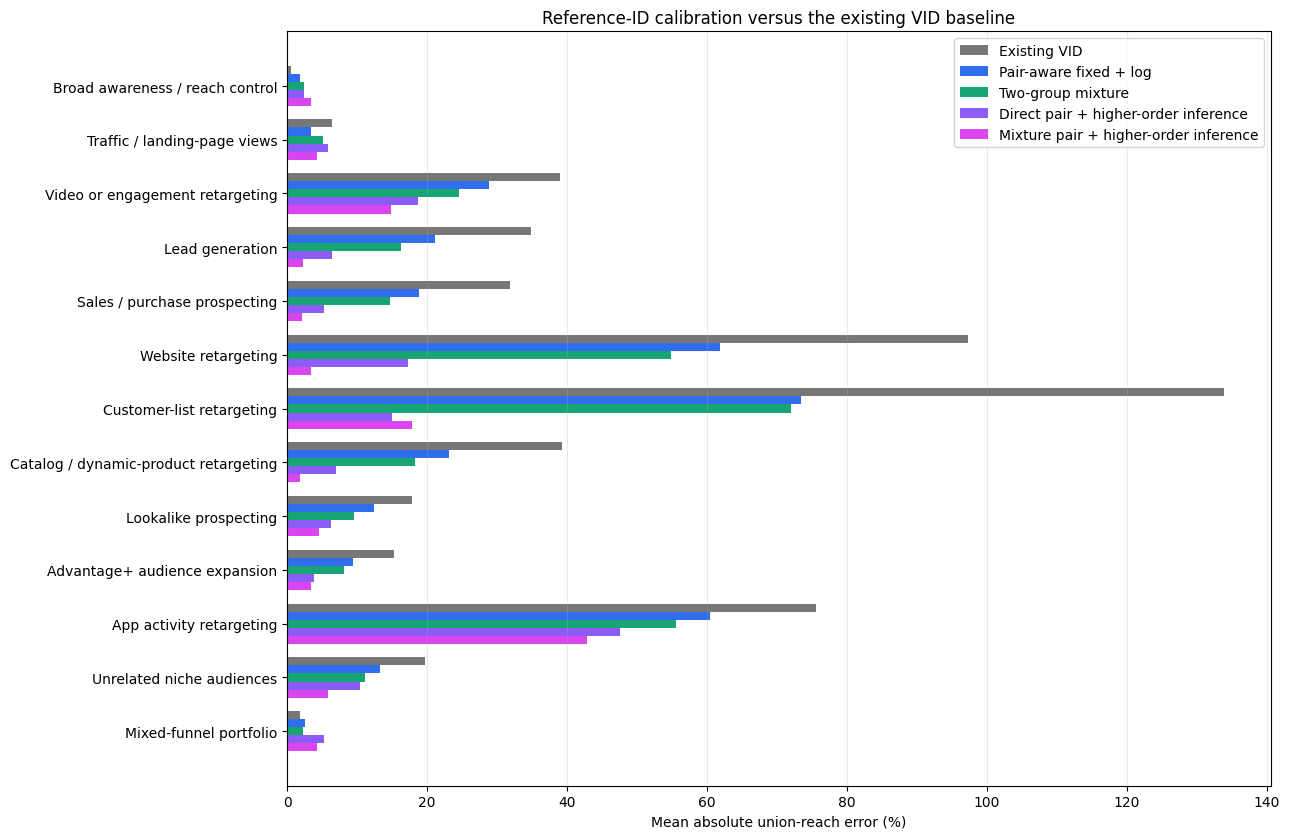

Saved outputs/meta_campaign_scenarios/meta_scenario_error_comparison.png


In [7]:
labels = [item["label"] for item in SCENARIO_CATALOG]
methods = [
    "baseline_vid",
    pair_model.name,
    mixture_model.name,
    PAIRWISE_METHOD,
    PAIRWISE_MIXTURE_METHOD,
]
colors = ["#777777", "#2f6fed", "#17a673", "#8b5cf6", "#d946ef"]
y = np.arange(len(labels))
height = 0.15

fig, axis = plt.subplots(figsize=(13, 8.5))
for index, (method, color) in enumerate(zip(methods, colors)):
    values = [
        100 * scenario_means[(info["scenario"], info["label"], method)]
        for info in SCENARIO_CATALOG
    ]
    axis.barh(
        y + (index - (len(methods) - 1) / 2) * height,
        values,
        height,
        label=METHOD_LABELS[method],
        color=color,
    )

axis.set_xlabel("Mean absolute union-reach error (%)")
axis.set_title("Reference-ID calibration versus the existing VID baseline")
axis.set_yticks(y, labels)
axis.invert_yaxis()
axis.grid(axis="x", alpha=0.25)
axis.legend()
fig.tight_layout()
chart_path = OUTPUT_DIR / "meta_scenario_error_comparison.png"
fig.savefig(chart_path, dpi=170)
plt.show()
print(f"Saved {chart_path.relative_to(PROJECT_ROOT)}")

## Accuracy as the number of EDPs grows

The higher-order problem becomes harder as more EDPs enter a report: there are more intersections to estimate, and the intersections involving many small campaigns can contain very little Reference-ID signal. The table makes that scaling cost visible rather than averaging it away.

In [8]:
size_summary = []
for edp_count in (2, 5, 10):
    values = {}
    for method in methods:
        selected = [
            row["relative_error"] for row in rows
            if row["edp_count"] == edp_count and row["method"] == method
        ]
        values[method] = (float(np.mean(selected)), float(np.quantile(selected, 0.90)))
    size_summary.append({
        "edps": edp_count,
        "existing_mean": f"{values['baseline_vid'][0]:.1%}",
        "pair_mean": f"{values[pair_model.name][0]:.1%}",
        "mixture_mean": f"{values[mixture_model.name][0]:.1%}",
        "inferred_mean": f"{values[PAIRWISE_METHOD][0]:.1%}",
        "mixture_inferred_mean": f"{values[PAIRWISE_MIXTURE_METHOD][0]:.1%}",
        "existing_p90": f"{values['baseline_vid'][1]:.1%}",
        "pair_p90": f"{values[pair_model.name][1]:.1%}",
        "mixture_p90": f"{values[mixture_model.name][1]:.1%}",
        "inferred_p90": f"{values[PAIRWISE_METHOD][1]:.1%}",
        "mixture_inferred_p90": f"{values[PAIRWISE_MIXTURE_METHOD][1]:.1%}",
    })

display(Markdown(markdown_table(
    size_summary,
    [
        ("edps", "EDPs in report"),
        ("existing_mean", "Existing mean"),
        ("pair_mean", "Pair-aware mean"),
        ("mixture_mean", "Mixture mean"),
        ("inferred_mean", "Direct pair + inference mean"),
        ("mixture_inferred_mean", "Mixture pair + inference mean"),
        ("existing_p90", "Existing p90"),
        ("pair_p90", "Pair-aware p90"),
        ("mixture_p90", "Mixture p90"),
        ("inferred_p90", "Direct pair + inference p90"),
        ("mixture_inferred_p90", "Mixture pair + inference p90"),
    ],
)))

| EDPs in report | Existing mean | Pair-aware mean | Mixture mean | Direct pair + inference mean | Mixture pair + inference mean | Existing p90 | Pair-aware p90 | Mixture p90 | Direct pair + inference p90 | Mixture pair + inference p90 |
|---|---|---|---|---|---|---|---|---|---|---|
| 2 | 12.7% | 5.2% | 3.9% | 2.7% | 3.4% | 37.4% | 12.3% | 7.2% | 8.5% | 9.5% |
| 5 | 39.5% | 28.6% | 25.7% | 12.3% | 9.7% | 100.4% | 66.3% | 62.7% | 27.3% | 28.8% |
| 10 | 66.1% | 42.4% | 38.4% | 19.8% | 12.6% | 189.3% | 133.7% | 122.2% | 41.9% | 32.1% |

## Sensitivity to audience similarity and Reference-ID matchability

The central scenarios above are only one plausible setting. This section reruns every campaign type under five assumptions:

- the central setting;
- weaker and stronger cross-EDP similarity, holding matchability fixed; and
- lower and higher Reference-ID matchability, holding audience similarity fixed.

Changing one dimension at a time makes the result interpretable. The similarity lever changes how strongly EDPs rank people using common signals without changing each EDP's requested reach. The matchability lever changes whether the selected people are easier or harder to link by the common email-derived Reference ID. It does not change the truth definition.

To keep the notebook reasonably fast, the sensitivity sweep uses full-flight reports with 2, 5, and 10 EDPs and two independently generated campaigns per setting.

In [9]:
SENSITIVITY_REPORTS = [
    ("full flight, 2 EDPs", tuple(range(13)), tuple(range(2))),
    ("full flight, 5 EDPs", tuple(range(13)), tuple(range(5))),
    ("full flight, 10 EDPs", tuple(range(13)), tuple(range(10))),
]


def scenario_variants(info):
    return [
        ("central", 1.0, 0.0),
        ("weaker similarity", info["similarity_low"], 0.0),
        ("stronger similarity", info["similarity_high"], 0.0),
        ("lower matchability", 1.0, info["matchability_low"]),
        ("higher matchability", 1.0, info["matchability_high"]),
    ]


def evaluate_sensitivity(campaigns_per_variant=2):
    sensitivity_rows = []
    for scenario_index, info in enumerate(SCENARIO_CATALOG):
        print(f"Sensitivity {scenario_index + 1:>2}/{len(SCENARIO_CATALOG)}: {info['label']}")
        for variant_index, (variant, similarity, matchability) in enumerate(scenario_variants(info)):
            for replicate in range(campaigns_per_variant):
                campaign = generate_campaign(
                    world,
                    info["scenario"],
                    config.seed + 4_000_000 + scenario_index * 100_000 + variant_index * 1_000 + replicate,
                    f"sensitivity_{info['scenario']}_{variant_index}_{replicate}",
                    similarity_multiplier=similarity,
                    matchability_shift=matchability,
                )
                for report_label, weeks, edps in SENSITIVITY_REPORTS:
                    observation = measure_report(world, campaign, weeks, edps)
                    truth = float(observation.truth_unions[-1])
                    estimates = {"baseline_vid": float(observation.baseline_unions[-1])}
                    for model in models:
                        estimates[model.name] = calibrate_report(observation, model).full_union
                    estimates[PAIRWISE_METHOD] = calibrate_report_pairwise_maximum_entropy(
                        observation,
                        direct_pair_model,
                        pair_ridge=1e-6,
                        evidence_half_saturation=0.1,
                        name=PAIRWISE_METHOD,
                    ).full_union
                    estimates[PAIRWISE_MIXTURE_METHOD] = calibrate_report_pairwise_maximum_entropy(
                        observation,
                        mixture_model,
                        pair_ridge=1e-6,
                        evidence_half_saturation=0.1,
                        name=PAIRWISE_MIXTURE_METHOD,
                    ).full_union
                    for method, estimate in estimates.items():
                        sensitivity_rows.append({
                            "scenario": info["scenario"],
                            "scenario_label": info["label"],
                            "variant": variant,
                            "similarity_multiplier": similarity,
                            "matchability_shift": matchability,
                            "replicate": replicate,
                            "report": report_label,
                            "edp_count": len(edps),
                            "method": method,
                            "method_label": METHOD_LABELS[method],
                            "relative_error": relative_error(estimate, truth),
                        })
    return sensitivity_rows


sensitivity_rows = evaluate_sensitivity(campaigns_per_variant=2)
print(f"Completed {len(sensitivity_rows):,} sensitivity observations.")

Sensitivity  1/13: Broad awareness / reach control


Sensitivity  2/13: Traffic / landing-page views


Sensitivity  3/13: Video or engagement retargeting


Sensitivity  4/13: Lead generation


Sensitivity  5/13: Sales / purchase prospecting


...

Sensitivity 10/13: Advantage+ audience expansion


Sensitivity 11/13: App activity retargeting


Sensitivity 12/13: Unrelated niche audiences


Sensitivity 13/13: Mixed-funnel portfolio


Completed 1,950 sensitivity observations.


In [10]:
variant_order = [
    "weaker similarity",
    "central",
    "stronger similarity",
    "lower matchability",
    "higher matchability",
]

baseline_sensitivity = grouped_mean(
    [row for row in sensitivity_rows if row["method"] == "baseline_vid"],
    ["scenario", "variant"],
)

sensitivity_improvement = {}
calibrated_method_ids = [
    pair_model.name,
    mixture_model.name,
    PAIRWISE_METHOD,
    PAIRWISE_MIXTURE_METHOD,
]
for method_name in calibrated_method_ids:
    calibrated_means = grouped_mean(
        [row for row in sensitivity_rows if row["method"] == method_name],
        ["scenario", "variant"],
    )
    for info in SCENARIO_CATALOG:
        for variant in variant_order:
            key = (info["scenario"], variant)
            sensitivity_improvement[(method_name, *key)] = (
                baseline_sensitivity[key] - calibrated_means[key]
            )

sensitivity_summary = []
for info in SCENARIO_CATALOG:
    row = {"scenario": info["label"]}
    for method_name, prefix in (
        (pair_model.name, "pair"),
        (mixture_model.name, "mixture"),
        (PAIRWISE_METHOD, "inferred"),
        (PAIRWISE_MIXTURE_METHOD, "mixture_inferred"),
    ):
        gains = [
            sensitivity_improvement[(method_name, info["scenario"], variant)]
            for variant in variant_order
        ]
        row[f"{prefix}_wins"] = f"{sum(value > 0 for value in gains)}/5"
        row[f"{prefix}_worst"] = f"{min(gains):+.1%}"
    sensitivity_summary.append(row)

display(Markdown(markdown_table(
    sensitivity_summary,
    [
        ("scenario", "Scenario"),
        ("pair_wins", "Pair-aware settings improved"),
        ("pair_worst", "Pair-aware worst gain"),
        ("mixture_wins", "Mixture settings improved"),
        ("mixture_worst", "Mixture worst gain"),
        ("inferred_wins", "Direct-pair settings improved"),
        ("inferred_worst", "Direct-pair worst gain"),
        ("mixture_inferred_wins", "Mixture-pair settings improved"),
        ("mixture_inferred_worst", "Mixture-pair worst gain"),
    ],
)))

print("A positive gain means the calibration reduced error versus existing VID; a negative gain means it made the estimate worse.")

| Scenario | Pair-aware settings improved | Pair-aware worst gain | Mixture settings improved | Mixture worst gain | Direct-pair settings improved | Direct-pair worst gain | Mixture-pair settings improved | Mixture-pair worst gain |
|---|---|---|---|---|---|---|---|---|
| Broad awareness / reach control | 1/5 | -2.1% | 0/5 | -3.5% | 1/5 | -1.6% | 0/5 | -3.6% |
| Traffic / landing-page views | 4/5 | -7.7% | 4/5 | -4.3% | 3/5 | -5.8% | 3/5 | -6.1% |
| Video or engagement retargeting | 5/5 | +5.9% | 5/5 | +10.6% | 5/5 | +14.6% | 5/5 | +17.4% |
| Lead generation | 5/5 | +13.9% | 5/5 | +18.3% | 5/5 | +23.4% | 5/5 | +26.6% |
| Sales / purchase prospecting | 5/5 | +10.0% | 5/5 | +16.0% | 5/5 | +21.9% | 5/5 | +23.5% |
| Website retargeting | 5/5 | +35.3% | 5/5 | +45.9% | 5/5 | +69.9% | 5/5 | +79.8% |
| Customer-list retargeting | 5/5 | +86.6% | 5/5 | +84.9% | 5/5 | +133.5% | 5/5 | +133.5% |
| Catalog / dynamic-product retargeting | 5/5 | +17.1% | 5/5 | +23.2% | 5/5 | +27.3% | 5/5 | +31.7% |
| Lookalike prospecting | 5/5 | +4.7% | 5/5 | +1.8% | 5/5 | +3.1% | 5/5 | +3.3% |
| Advantage+ audience expansion | 5/5 | +2.9% | 5/5 | +2.6% | 5/5 | +4.2% | 5/5 | +3.3% |
| App activity retargeting | 5/5 | +17.9% | 5/5 | +24.8% | 5/5 | +31.7% | 5/5 | +35.0% |
| Unrelated niche audiences | 5/5 | +5.9% | 5/5 | +8.4% | 5/5 | +2.6% | 5/5 | +4.9% |
| Mixed-funnel portfolio | 2/5 | -4.5% | 2/5 | -4.0% | 2/5 | -8.1% | 1/5 | -9.6% |

A positive gain means the calibration reduced error versus existing VID; a negative gain means it made the estimate worse.


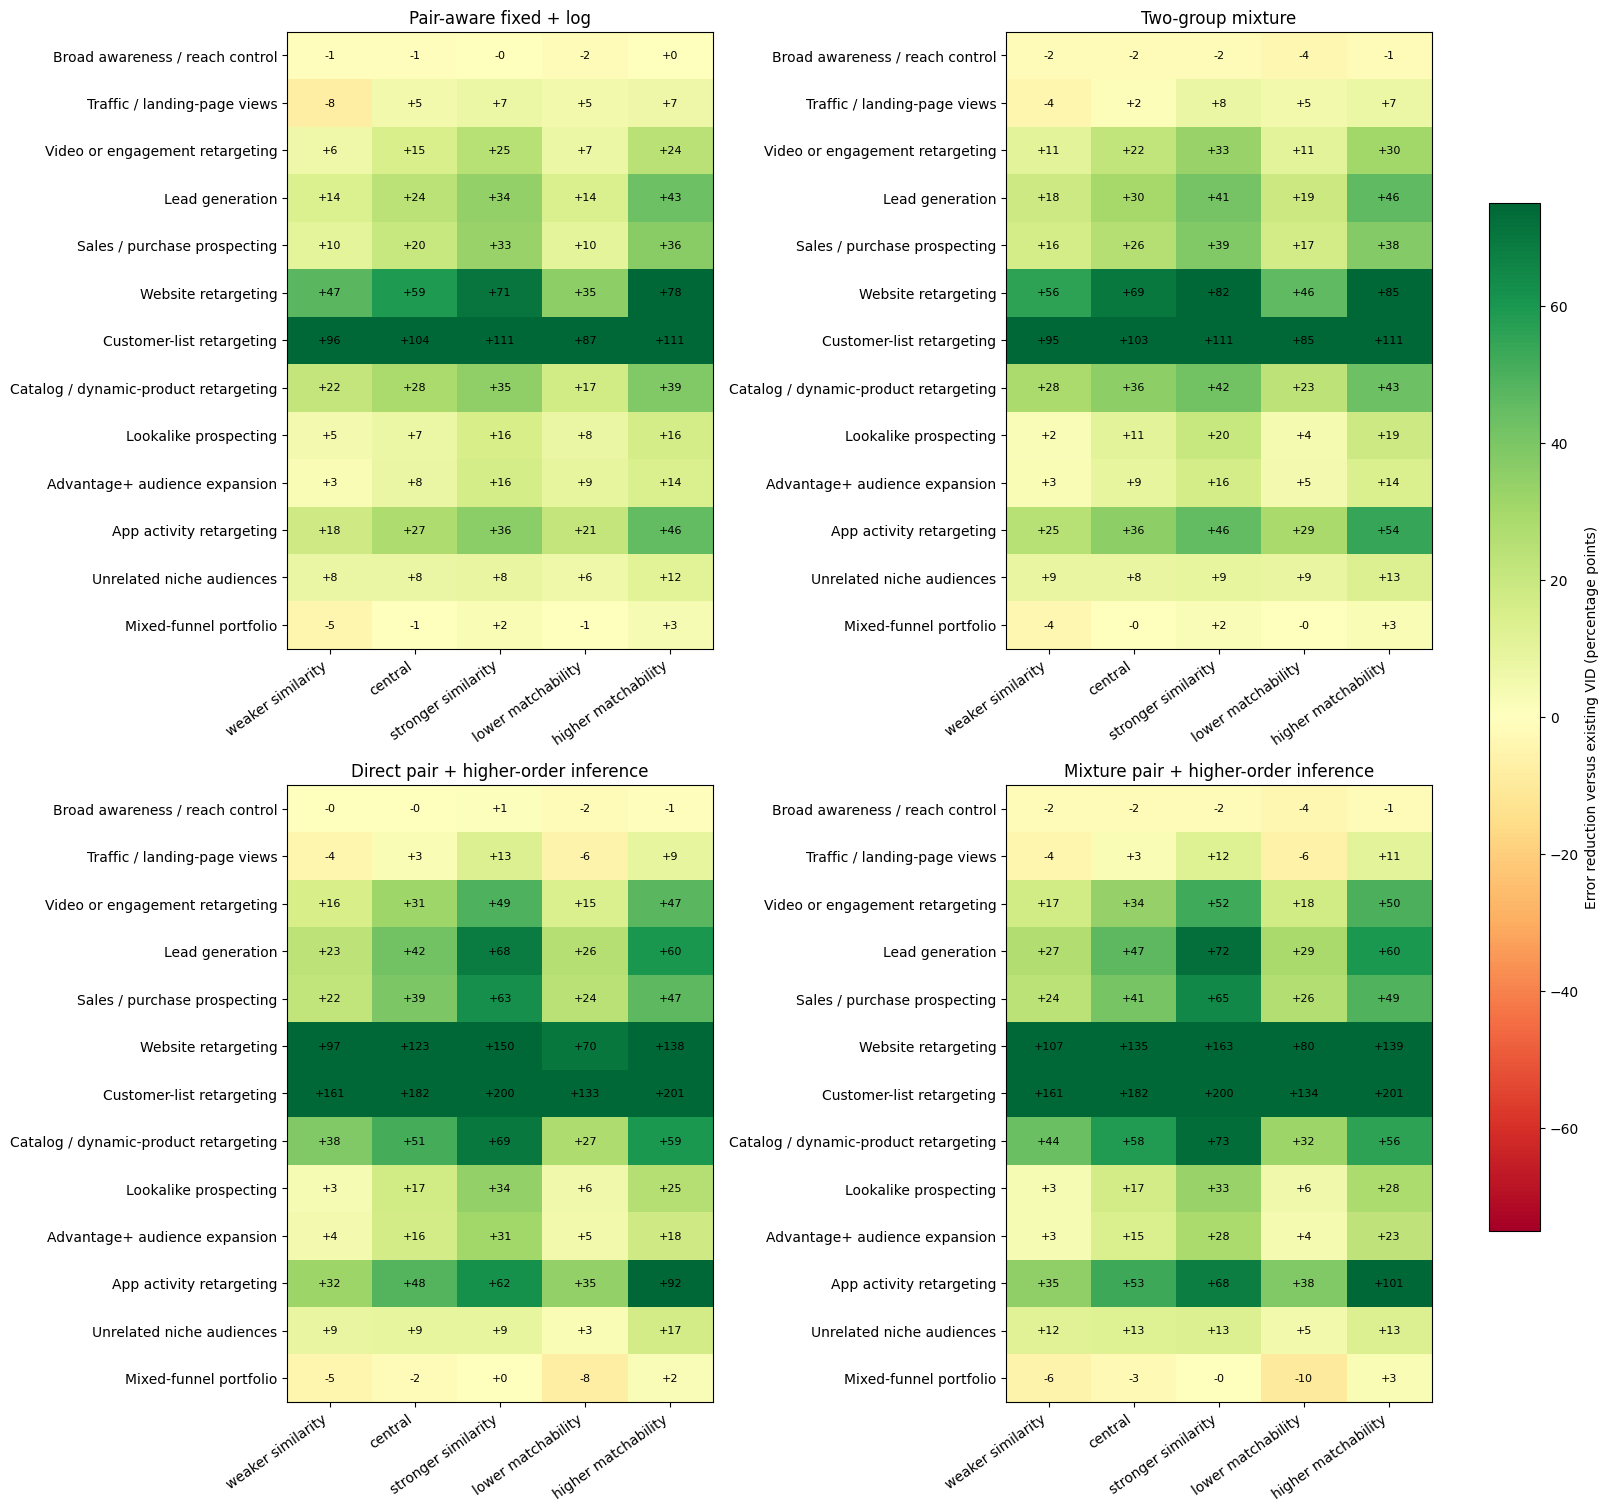

Saved outputs/meta_campaign_scenarios/meta_scenario_sensitivity.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 15), constrained_layout=True)
axes = axes.ravel()
max_abs = max(abs(value) for value in sensitivity_improvement.values()) * 100
limit = max(10.0, min(75.0, np.ceil(max_abs / 5) * 5))

for axis, method_name in zip(axes, calibrated_method_ids):
    matrix = np.array([
        [
            100 * sensitivity_improvement[(method_name, info["scenario"], variant)]
            for variant in variant_order
        ]
        for info in SCENARIO_CATALOG
    ])
    image = axis.imshow(matrix, cmap="RdYlGn", vmin=-limit, vmax=limit, aspect="auto")
    axis.set_title(METHOD_LABELS[method_name])
    axis.set_xticks(np.arange(len(variant_order)), variant_order, rotation=35, ha="right")
    axis.set_yticks(np.arange(len(SCENARIO_CATALOG)), [info["label"] for info in SCENARIO_CATALOG])
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            axis.text(column_index, row_index, f"{value:+.0f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=axes, shrink=0.75, label="Error reduction versus existing VID (percentage points)")
sensitivity_chart_path = OUTPUT_DIR / "meta_scenario_sensitivity.png"
fig.savefig(sensitivity_chart_path, dpi=170, bbox_inches="tight")
plt.show()
print(f"Saved {sensitivity_chart_path.relative_to(PROJECT_ROOT)}")

## Results for specific report requests

These rows show the combinations most likely to expose problems: short early-flight reports, two small correlated campaigns, five-EDP partial windows, and full ten-EDP reports. The values are averages over the three generated campaigns for that scenario.

In [12]:
SPOTLIGHTS = [
    ("broad_awareness_control", "full flight, 10 EDPs"),
    ("sales_prospecting", "weeks 1-3, 10 EDPs"),
    ("sales_prospecting", "full flight, 10 EDPs"),
    ("website_retargeting", "weeks 5-12, 2 EDPs"),
    ("crm_customer_list", "full flight, 2 EDPs"),
    ("catalog_retargeting", "weeks 7-13, 5 EDPs"),
    ("advantage_audience_expansion", "full flight, 5 selected EDPs"),
    ("app_activity_retargeting", "noncontiguous weeks, 5 EDPs"),
    ("unrelated_niche_control", "full flight, 5 selected EDPs"),
    ("mixed_funnel_portfolio", "full flight, 10 EDPs"),
]

spotlight_rows = []
for scenario, report in SPOTLIGHTS:
    info = next(item for item in SCENARIO_CATALOG if item["scenario"] == scenario)
    values = {}
    for method in methods:
        selected = [
            row["relative_error"] for row in rows
            if row["scenario"] == scenario and row["report"] == report and row["method"] == method
        ]
        values[method] = float(np.mean(selected))
    spotlight_rows.append({
        "scenario": info["label"],
        "report": report,
        "existing": f"{values['baseline_vid']:.1%}",
        "pair": f"{values[pair_model.name]:.1%}",
        "mixture": f"{values[mixture_model.name]:.1%}",
        "inferred": f"{values[PAIRWISE_METHOD]:.1%}",
        "mixture_inferred": f"{values[PAIRWISE_MIXTURE_METHOD]:.1%}",
    })

display(Markdown(markdown_table(
    spotlight_rows,
    [
        ("scenario", "Scenario"),
        ("report", "Report request"),
        ("existing", "Existing VID error"),
        ("pair", "Pair-aware error"),
        ("mixture", "Mixture error"),
        ("inferred", "Direct pair + inference"),
        ("mixture_inferred", "Mixture pair + inference"),
    ],
)))

| Scenario | Report request | Existing VID error | Pair-aware error | Mixture error | Direct pair + inference | Mixture pair + inference |
|---|---|---|---|---|---|---|
| Broad awareness / reach control | full flight, 10 EDPs | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% |
| Sales / purchase prospecting | weeks 1-3, 10 EDPs | 19.7% | 15.9% | 12.5% | 6.0% | 4.0% |
| Sales / purchase prospecting | full flight, 10 EDPs | 66.7% | 35.0% | 26.9% | 12.9% | 4.9% |
| Website retargeting | weeks 5-12, 2 EDPs | 31.3% | 11.2% | 4.1% | 0.9% | 1.0% |
| Customer-list retargeting | full flight, 2 EDPs | 64.1% | 0.4% | 5.1% | 11.3% | 11.3% |
| Catalog / dynamic-product retargeting | weeks 7-13, 5 EDPs | 34.2% | 22.5% | 15.5% | 5.4% | 2.2% |
| Advantage+ audience expansion | full flight, 5 selected EDPs | 22.5% | 19.0% | 17.9% | 3.5% | 3.5% |
| App activity retargeting | noncontiguous weeks, 5 EDPs | 49.5% | 45.0% | 42.2% | 36.5% | 31.6% |
| Unrelated niche audiences | full flight, 5 selected EDPs | 53.3% | 38.7% | 34.1% | 25.1% | 14.8% |
| Mixed-funnel portfolio | full flight, 10 EDPs | 3.4% | 5.3% | 4.1% | 10.1% | 6.9% |

## Early report versus later full-flight rerun

No prior report result is needed to reproduce a later calibrated estimate: the frozen model-line calibration is applied to the Reference-ID and VID aggregates measured for the newly requested window. The following table compares weeks 1–3, weeks 1–12, and the full 13-week flight for the same ten EDPs. Cross-report reconciliation could still be applied afterward if published reports must obey additional historical constraints.

In [13]:
timeline_reports = {"weeks 1-3, 10 EDPs", "weeks 1-12, 10 EDPs", "full flight, 10 EDPs"}
timeline_scenarios = {"sales_prospecting", "website_retargeting", "mixed_funnel_portfolio"}
timeline = []
for scenario in timeline_scenarios:
    label = next(item["label"] for item in SCENARIO_CATALOG if item["scenario"] == scenario)
    for report, _, _ in REPORT_SPECS:
        if report not in timeline_reports:
            continue
        values = {}
        for method in methods:
            selected = [
                row["relative_error"] for row in rows
                if row["scenario"] == scenario and row["report"] == report and row["method"] == method
            ]
            values[method] = float(np.mean(selected))
        timeline.append({
            "scenario": label,
            "report": report,
            "existing": f"{values['baseline_vid']:.1%}",
            "pair": f"{values[pair_model.name]:.1%}",
            "mixture": f"{values[mixture_model.name]:.1%}",
            "inferred": f"{values[PAIRWISE_METHOD]:.1%}",
            "mixture_inferred": f"{values[PAIRWISE_MIXTURE_METHOD]:.1%}",
        })

display(Markdown(markdown_table(
    timeline,
    [
        ("scenario", "Scenario"),
        ("report", "Cumulative report"),
        ("existing", "Existing VID error"),
        ("pair", "Pair-aware error"),
        ("mixture", "Mixture error"),
        ("inferred", "Direct pair + inference"),
        ("mixture_inferred", "Mixture pair + inference"),
    ],
)))

| Scenario | Cumulative report | Existing VID error | Pair-aware error | Mixture error | Direct pair + inference | Mixture pair + inference |
|---|---|---|---|---|---|---|
| Website retargeting | weeks 1-3, 10 EDPs | 56.7% | 46.8% | 41.9% | 23.7% | 4.6% |
| Website retargeting | weeks 1-12, 10 EDPs | 219.1% | 139.5% | 129.4% | 44.8% | 1.6% |
| Website retargeting | full flight, 10 EDPs | 226.4% | 143.1% | 134.9% | 37.3% | 3.1% |
| Sales / purchase prospecting | weeks 1-3, 10 EDPs | 19.7% | 15.9% | 12.5% | 6.0% | 4.0% |
| Sales / purchase prospecting | weeks 1-12, 10 EDPs | 65.6% | 34.6% | 26.1% | 13.7% | 4.5% |
| Sales / purchase prospecting | full flight, 10 EDPs | 66.7% | 35.0% | 26.9% | 12.9% | 4.9% |
| Mixed-funnel portfolio | weeks 1-3, 10 EDPs | 2.0% | 0.9% | 0.7% | 3.8% | 3.4% |
| Mixed-funnel portfolio | weeks 1-12, 10 EDPs | 3.6% | 5.2% | 3.6% | 10.6% | 6.5% |
| Mixed-funnel portfolio | full flight, 10 EDPs | 3.4% | 5.3% | 4.1% | 10.1% | 6.9% |

## Guardrails and cases where calibration does not help

A credible test should not claim universal improvement. The next cell reports how often each method beats the existing VID estimate, identifies the largest regressions, and verifies that every calibrated report remains inside elementary reach bounds while preserving the per-EDP VID reaches.

In [14]:
baseline_lookup = {
    (row["scenario"], row["campaign"], row["report"]): row["relative_error"]
    for row in rows if row["method"] == "baseline_vid"
}

guardrail_rows = []
for method_name in calibrated_method_ids:
    model_rows = [row for row in rows if row["method"] == method_name]
    improvements = np.array([
        baseline_lookup[(row["scenario"], row["campaign"], row["report"])] - row["relative_error"]
        for row in model_rows
    ])
    guardrail_rows.append({
        "method": METHOD_LABELS[method_name],
        "beats_today": f"{np.mean(improvements > 0):.1%}",
        "mean_gain": f"{np.mean(improvements):+.1%}",
        "p10_gain": f"{np.quantile(improvements, 0.10):+.1%}",
        "worst_regression": f"{np.min(improvements):+.1%}",
    })

display(Markdown(markdown_table(
    guardrail_rows,
    [
        ("method", "Method"),
        ("beats_today", "Reports with lower error"),
        ("mean_gain", "Mean error reduction"),
        ("p10_gain", "10th-percentile gain"),
        ("worst_regression", "Worst regression"),
    ],
)))

failed_bounds = sum(not check["bounds_ok"] for check in calibrated_checks)
max_marginal_error = max(check["marginal_error"] for check in calibrated_checks)
max_residual = max(check["decoder_residual"] for check in calibrated_checks)
print(f"Calibrated reports checked: {len(calibrated_checks):,}")
print(f"Elementary reach-bound violations: {failed_bounds}")
print(f"Largest change to any per-EDP VID reach: {max_marginal_error:,.6f} people")
print(f"Largest normalized decoder residual: {max_residual:.3f}")

| Method | Reports with lower error | Mean error reduction | 10th-percentile gain | Worst regression |
|---|---|---|---|---|
| Pair-aware fixed + log | 85.2% | +14.0% | -0.2% | -7.1% |
| Two-group mixture | 87.7% | +16.8% | -0.0% | -7.7% |
| Direct pair + higher-order inference | 82.3% | +27.9% | -0.8% | -8.7% |
| Mixture pair + higher-order inference | 84.3% | +30.9% | -1.2% | -8.0% |

Calibrated reports checked: 1,404
Elementary reach-bound violations: 0
Largest change to any per-EDP VID reach: 0.090106 people
Largest normalized decoder residual: 0.261


In [15]:
regressions = []
for row in rows:
    if row["method"] == "baseline_vid":
        continue
    baseline_error = baseline_lookup[(row["scenario"], row["campaign"], row["report"])]
    change = baseline_error - row["relative_error"]
    if change < 0:
        regressions.append({**row, "gain": change, "baseline_error": baseline_error})

regressions.sort(key=lambda item: item["gain"])
worst_rows = [
    {
        "scenario": row["scenario_label"],
        "report": row["report"],
        "method": row["method_label"],
        "today": f"{row['baseline_error']:.1%}",
        "calibrated": f"{row['relative_error']:.1%}",
        "change": f"{row['gain']:+.1%}",
    }
    for row in regressions[:12]
]

display(Markdown("### Largest individual regressions\n\n" + markdown_table(
    worst_rows,
    [
        ("scenario", "Scenario"),
        ("report", "Report"),
        ("method", "Calibration"),
        ("today", "Existing VID error"),
        ("calibrated", "Calibrated error"),
        ("change", "Error reduction"),
    ],
)))

### Largest individual regressions

| Scenario | Report | Calibration | Existing VID error | Calibrated error | Error reduction |
|---|---|---|---|---|---|
| Broad awareness / reach control | noncontiguous weeks, 5 EDPs | Direct pair + higher-order inference | 0.0% | 8.8% | -8.7% |
| Broad awareness / reach control | full flight, 2 EDPs | Mixture pair + higher-order inference | 0.1% | 8.2% | -8.0% |
| Mixed-funnel portfolio | weeks 1-12, 10 EDPs | Direct pair + higher-order inference | 3.5% | 11.3% | -7.8% |
| Broad awareness / reach control | full flight, 2 EDPs | Two-group mixture | 0.1% | 7.9% | -7.7% |
| Mixed-funnel portfolio | full flight, 5 selected EDPs | Mixture pair + higher-order inference | 1.6% | 9.0% | -7.3% |
| Mixed-funnel portfolio | full flight, 5 selected EDPs | Direct pair + higher-order inference | 1.6% | 8.9% | -7.2% |
| Broad awareness / reach control | noncontiguous weeks, 5 EDPs | Pair-aware fixed + log | 0.0% | 7.1% | -7.1% |
| Mixed-funnel portfolio | noncontiguous weeks, 5 EDPs | Direct pair + higher-order inference | 1.1% | 8.1% | -6.9% |
| Mixed-funnel portfolio | noncontiguous weeks, 5 EDPs | Direct pair + higher-order inference | 0.5% | 7.4% | -6.9% |
| Broad awareness / reach control | full flight, 2 EDPs | Mixture pair + higher-order inference | 0.6% | 7.5% | -6.9% |
| Mixed-funnel portfolio | full flight, 10 EDPs | Direct pair + higher-order inference | 3.5% | 10.4% | -6.9% |
| Broad awareness / reach control | noncontiguous weeks, 5 EDPs | Direct pair + higher-order inference | 0.6% | 7.5% | -6.9% |

## Interpretation

Use the results as an engineering and validation demonstration, not as a production accuracy claim.

- **Broad awareness is the control.** A useful calibration should be roughly neutral when the existing population-rate assumption is already reasonable.
- **Retargeting and lower-funnel scenarios are the main opportunity.** They create the strongest departure from population-rate overlap, so the existing VID baseline can overstate union reach substantially.
- **Customer-list and app scenarios test transfer risk.** The Reference-ID linkage rate can change with audience selection; a frozen calibration can become biased even when the observed match counts are measured correctly.
- **Lookalike and audience expansion test the middle ground.** These should be less extreme than retargeting and more selected than broad reach.
- **Unrelated niches are a safety check.** Calibration should not manufacture overlap merely because the campaigns are small.
- **Ten EDPs test higher-order overlap.** The original calibrated methods use measured intersections through all orders. The direct-pair method instead calibrates all pairs and infers the remaining structure with one maximum-entropy audience table.
- **The sensitivity sweep is more important than any one synthetic coefficient.** A scenario is robust only when its conclusion survives both weaker/stronger audience similarity and lower/higher Reference-ID matchability.

The decisive next step is to recreate this notebook with approved aggregate observations from real campaigns and whole-campaign holdouts. That validation should determine whether the pair-aware model, the matchability mixture, a direct capture-rate model, or another predeclared model transfers best to actual traffic.

In [16]:
metrics_path = OUTPUT_DIR / "meta_campaign_scenario_metrics.csv"
fieldnames = list(rows[0].keys())
with metrics_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.DictWriter(stream, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

sensitivity_path = OUTPUT_DIR / "meta_campaign_sensitivity_metrics.csv"
sensitivity_fields = list(sensitivity_rows[0].keys())
with sensitivity_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.DictWriter(stream, fieldnames=sensitivity_fields)
    writer.writeheader()
    writer.writerows(sensitivity_rows)

summary_path = OUTPUT_DIR / "meta_campaign_scenario_summary.json"
summary_path.write_text(json.dumps({
    "scenario_count": len(SCENARIO_CATALOG),
    "campaigns_per_scenario": 3,
    "report_shapes": len(REPORT_SPECS),
    "models": [model.describe() for model in models] + [direct_pair_model.describe()],
    "scenario_summary": scenario_summary,
    "sensitivity_assumptions": SENSITIVITY_ASSUMPTIONS,
    "sensitivity_summary": sensitivity_summary,
    "guardrails": {
        "calibrated_reports_checked": len(calibrated_checks),
        "elementary_bound_violations": failed_bounds,
        "maximum_marginal_change_people": max_marginal_error,
        "maximum_decoder_residual": max_residual,
    },
}, indent=2), encoding="utf-8")

print(f"Saved detailed metrics: {metrics_path.relative_to(PROJECT_ROOT)}")
print(f"Saved sensitivity metrics: {sensitivity_path.relative_to(PROJECT_ROOT)}")
print(f"Saved summary: {summary_path.relative_to(PROJECT_ROOT)}")

Saved detailed metrics: outputs/meta_campaign_scenarios/meta_campaign_scenario_metrics.csv
Saved sensitivity metrics: outputs/meta_campaign_scenarios/meta_campaign_sensitivity_metrics.csv
Saved summary: outputs/meta_campaign_scenarios/meta_campaign_scenario_summary.json
